In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import nltk
import warnings
%matplotlib.inline
warnings.filterwarnings('ignore')
#https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv

UsageError: Line magic function `%matplotlib.inline` not found.


In [ ]:
data=pd.read_csv("https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv",encoding='latin1')

In [145]:
data.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [146]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [150]:
from nltk.stem.porter import PorterStemmer
stemmer = PorterStemmer()
def clean_text(text):
    # remove mentions
    text = re.sub(r'@[\w]*', '', text)

    # remove special characters & numbers
    text = re.sub(r'[^a-zA-Z#]', ' ', text)

    # lowercase
    text = text.lower()

    # split into words
    words = text.split()

    # remove short words
    words = [w for w in words if len(w) > 3]

    # stemming
    words = [stemmer.stem(word) for word in words]

    return " ".join(words)

# APPLY HERE
data['clean_tweet'] = data['tweet'].apply(clean_text)

In [151]:
pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


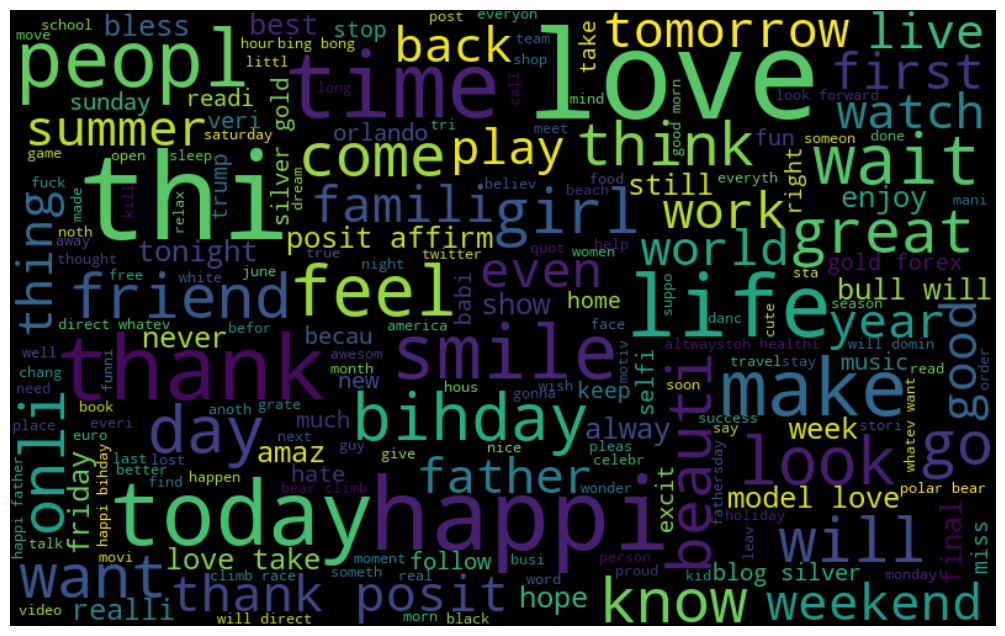

In [152]:
#visualize frequent words
all_words=" ".join([x for x in data['clean_tweet']])
from wordcloud import WordCloud
wordcloud= WordCloud(width=800,height=500,random_state=42,max_font_size=100).generate(all_words)
#plot the graph
plt.figure(figsize=(15,8))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()

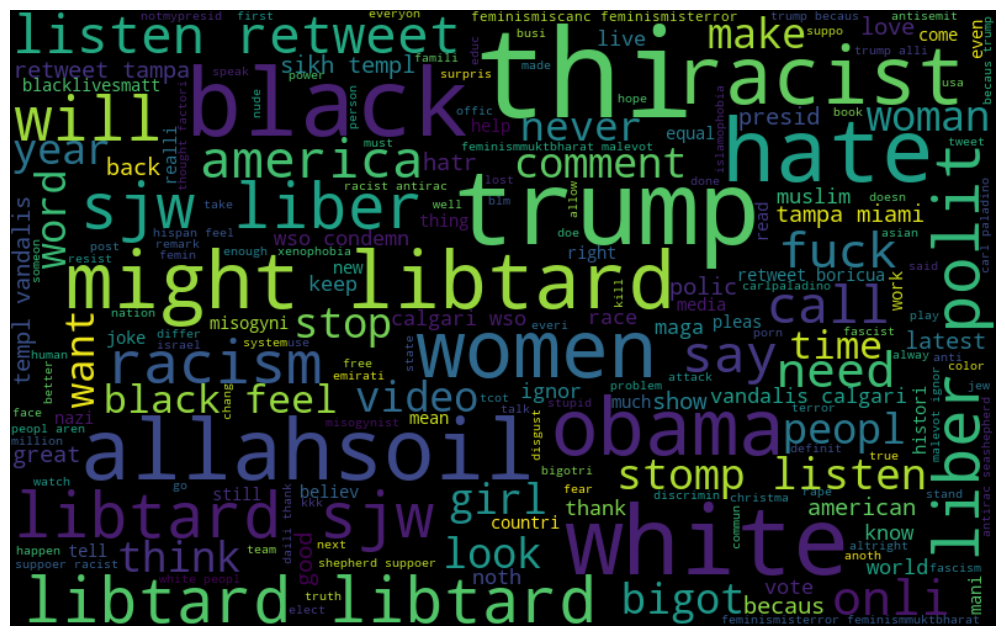

In [153]:
all_words=" ".join([x for x in data['clean_tweet'][data['label']==1]])
wordcloud= WordCloud(width=800,height=500,random_state=42,max_font_size=100).generate(all_words)
#plot the graph
plt.figure(figsize=(15,8))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()

In [110]:
# #exract he hashtag
# def hashtag_extract(tweets):
#     hashtags=[]
# #loop words in the tweet
#     for tweet in tweets:
#        ht=re.findall(r"#(\w+)",tweet)
#        hashtags.append(ht)ht_positive
#     return hashtags


In [154]:
#extract hashtags from non racist/sexist tweets  
ht_positive=hashtag_extract(data['clean_tweet'][data['label']==0])
#extract hashtags from racist/sexist tweets
ht_negative=hashtag_extract(data['clean_tweet'][data['label']==1])

In [112]:
ht_positive

[['run'],
 ['lyft', 'disapoint', 'getthank'],
 [],
 ['model'],
 ['motiv'],
 ['allshowandnogo'],
 [],
 ['school', 'exam', 'hate', 'imagin', 'actorslif', 'revolutionschool', 'girl'],
 ['allin', 'cav', 'champion', 'cleveland', 'clevelandcavali'],
 [],
 ['ireland', 'blog', 'silver', 'gold', 'forex'],
 ['orlando',
  'standwithorlando',
  'pulseshoot',
  'orlandoshoot',
  'biggerproblem',
  'selfish',
  'heabreak',
  'valu',
  'love'],
 ['gettingf'],
 ['got', 'junior', 'yugyoem', 'omg'],
 ['thank', 'posit'],
 ['friday', 'cooki'],
 [],
 ['euro'],
 ['badday', 'coneofsham', 'cat', 'piss', 'funni', 'laugh'],
 ['wine', 'weekend'],
 ['tgif', 'gamedev', 'indiedev', 'indiegamedev', 'squad'],
 ['upsideofflorida', 'shopalyssa', 'love'],
 ['smile', 'media', 'pressconfer', 'antalya', 'turkey', 'throwback'],
 ['ica'],
 [],
 ['rip', 'orlando'],
 [],
 ['alohafriday', 'time', 'not', 'exist', 'positivevib', 'hawaiian'],
 [],
 ['goodnight', 'badmonday'],
 ['taylorswift'],
 ['travelingram', 'dalat', 'ripinkyli

In [155]:
ht_negative

[['cnn', 'michigan', 'tcot'],
 ['australia',
  'opkillingbay',
  'seashepherd',
  'helpcovedolphin',
  'thecov',
  'helpcovedolphin'],
 [],
 [],
 ['neverump', 'xenophobia'],
 ['love', 'peac'],
 [],
 ['race', 'ident', 'med'],
 ['altright', 'whitesupremaci'],
 ['linguist', 'race', 'power', 'raciolinguist'],
 ['brexit'],
 ['peopl', 'trump', 'republican'],
 ['michelleobama'],
 ['knick', 'golf'],
 ['jewishsupremacist'],
 ['libtard', 'sjw', 'liber', 'polit'],
 ['trash', 'hate'],
 [],
 [],
 ['stereotyp', 'prejudic', 'hope', 'hate', 'conflict'],
 ['pol', 'bluelivesmatt', 'draintheswamp', 'ferguson'],
 [],
 ['antisemit', 'hocoschool', 'columbiamd', 'hocomd'],
 ['nazi', 'hatr', 'bigotri'],
 ['libtard', 'sjw', 'liber', 'polit'],
 ['fyi', 'tcot'],
 ['topoli'],
 ['blacklivesmatt'],
 ['ushistori', 'eugen'],
 ['biher', 'bigotri', 'altright', 'potu', 'theresist'],
 ['crime', 'offic'],
 [],
 ['black', 'retweet', 'tampa', 'miami'],
 ['allahsoil'],
 [],
 ['prais', 'cleveland', 'rnc', 'white', 'tamirric',

In [156]:
  ht_positive[:5]

[['run'], ['lyft', 'disapoint', 'getthank'], [], ['model'], ['motiv']]

In [157]:
# ht_positive=sum(ht_positive,[])
# ht_negative=sum(ht_negative,[])

In [158]:
ht_positive[:5]

[['run'], ['lyft', 'disapoint', 'getthank'], [], ['model'], ['motiv']]

In [159]:
ht_negative[:5]

[['cnn', 'michigan', 'tcot'],
 ['australia',
  'opkillingbay',
  'seashepherd',
  'helpcovedolphin',
  'thecov',
  'helpcovedolphin'],
 [],
 [],
 ['neverump', 'xenophobia']]

In [160]:
# freq=nltk.FreqDist(ht_positive)
# d=pd.DataFrame({'Hashtag':list(freq.keys()),
#                 'Count':list(freq.values())})
# d.head()

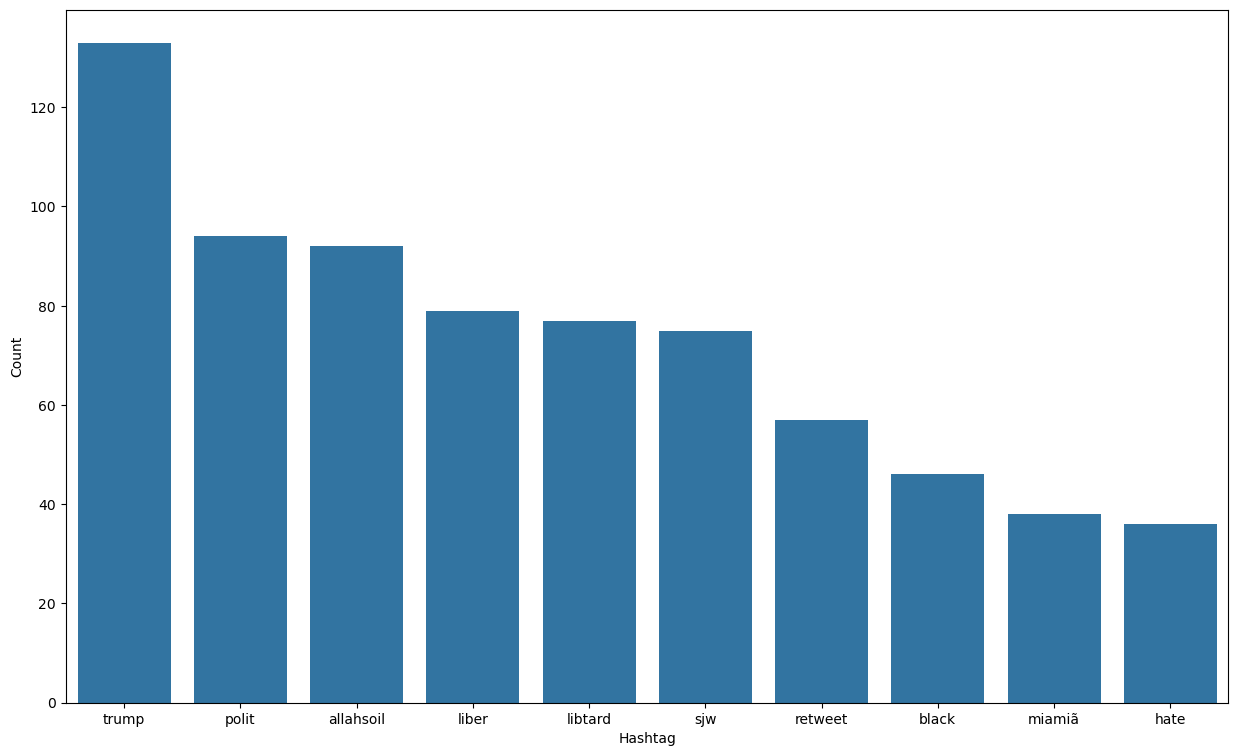

In [161]:
#selecting top 10 hashtags     
d=d.nlargest(columns='Count',n=10)
plt.figure(figsize=(15,9))
sns.barplot(data=d,x='Hashtag',y='Count')
plt.show()

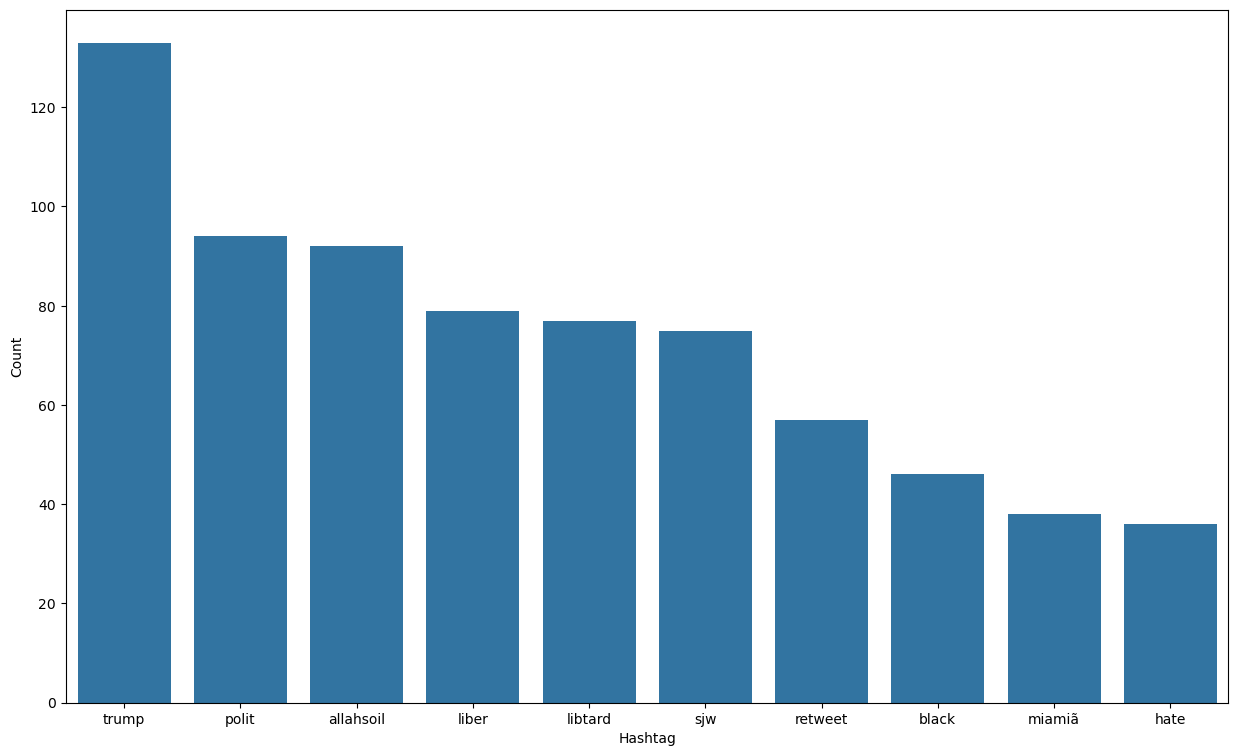

In [162]:
#selecting top 10 hashtags     
d=d.nlargest(columns='Count',n=10)
plt.figure(figsize=(15,9))
sns.barplot(data=d,x='Hashtag',y='Count')
plt.show()

In [163]:
# #feature extrction
# from sklearn.feature_extraction.text import CountVectorizer
# import pickle

# # preprocessing already done
# bow_vectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=5000, stop_words='english')

# # FIT on training data
# X = bow_vectorizer.fit_transform(data['clean_tweet'])


In [164]:
# X[0].toarray()

In [165]:
from sklearn.utils import resample

# separate classes
df_majority = data[data.label == 0]
df_minority = data[data.label == 1]

# upsample minority (positive)
df_minority_upsampled = resample(df_minority,
                                replace=True,
                                n_samples=len(df_majority),
                                random_state=42)

# combine
data_balanced = pd.concat([df_majority, df_minority_upsampled])

In [167]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer
bow_vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=1,
    max_features=5000,
    stop_words='english'
)  

In [168]:
X = bow_vectorizer.fit_transform(data_balanced['clean_tweet'])
y = data_balanced['label'] 

In [169]:
# accuracy_score(y_test,pred)  
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)        

In [170]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [172]:

model.score(x_test, y_test)

0.9721399730820997

In [173]:
import pickle

pickle.dump(model, open('sentiment_model.pkl', 'wb'))
pickle.dump(bow_vectorizer, open('vectorizer.pkl', 'wb'))  # very important!

In [174]:
# print(data_balanced['label'].value_counts())